Saved: ../output/refinement_figures/combined_cache_efficiency.pdf


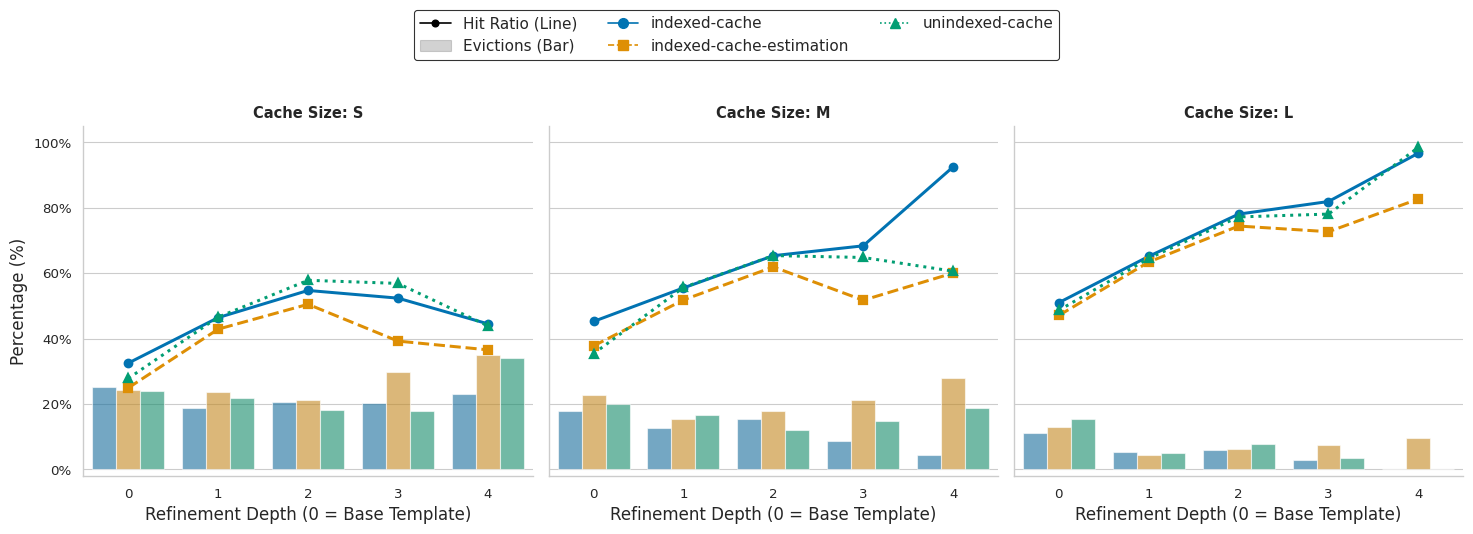

Saved: ../output/refinement_figures/temporal_throughput_line.pdf


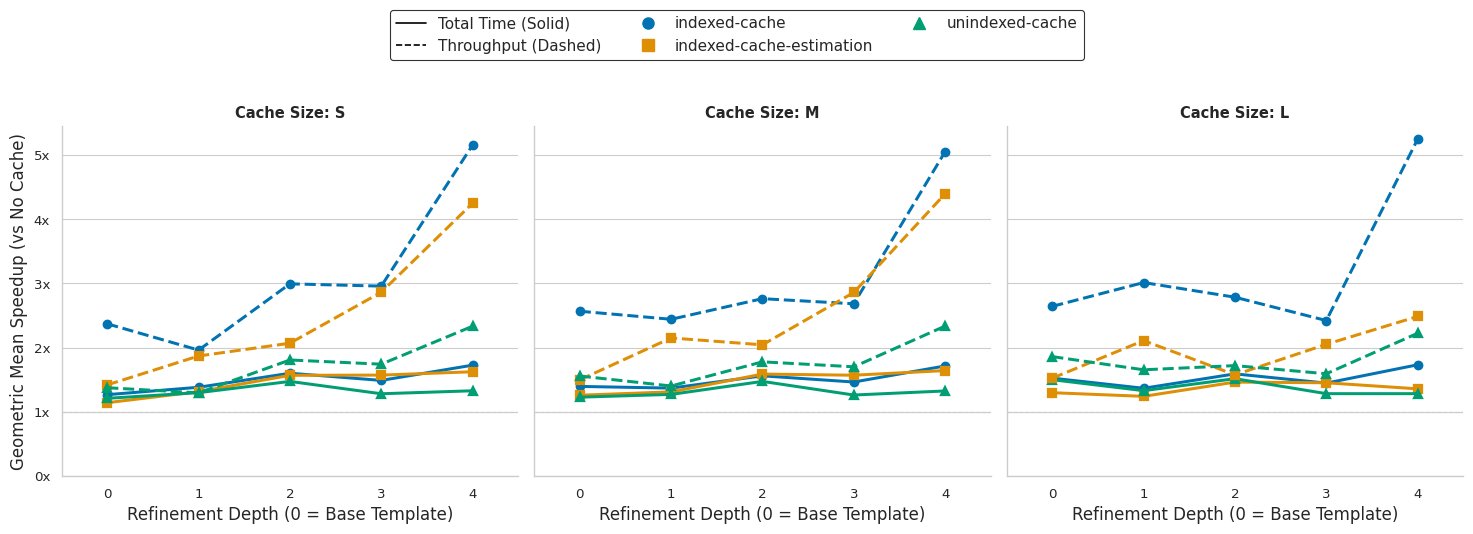

In [20]:
import os
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.stats import gmean

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

def safe_gmean(x):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    valid_x = x.dropna()
    valid_x = valid_x[valid_x > 0]
    if valid_x.empty:
        return np.nan
    return gmean(valid_x)

def get_algorithm_labels(locations):
    """
    Takes a list of file paths and returns a list of formatted algorithm labels.
    """
    def map_single(location_string):
        filename = os.path.basename(location_string).replace('.json', '')
        clean_name = filename.replace('query-results-raw-', '')

        # Extract size suffix and base algorithm name
        if clean_name[-2:].lower() in ['-s', '-m', '-l']:
            size = clean_name[-1].lower()
            base_type = clean_name[:-2]
        else:
            return clean_name  # Fallback if no valid size suffix exists

        # Apply mapping rules
        mapping = {
            'cache': 'unindexed-cache',
            'query-cache': 'indexed-cache',
            'query-cache-estimate': 'indexed-cache-estimation'
        }

        mapped_type = mapping.get(base_type, base_type)
        return f"{mapped_type}-{size}"

    return [map_single(loc) for loc in locations]


def investigate_refinement_patterns(baseline_locations, cache_locations, custom_labels=None):
    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                seq_element = item.get('sequenceElement', {})
                refinement_meta = seq_element.get('refinementMetadata', {})

                # Calculate depth from patternIds array
                pattern_ids = refinement_meta.get('patternIds', []) if isinstance(refinement_meta, dict) else []
                refinement_depth = len(pattern_ids)

                time_val = item.get('time')
                timestamps = item.get("timestamps", [])
                num_timestamps = len(timestamps)

                # Strict filtering
                time_first = timestamps[0] if num_timestamps > 0 else pd.NA
                time_last = timestamps[-1] if num_timestamps > 0 else pd.NA
                has_results = num_timestamps > 0

                # Pre-calculate temporal and throughput metrics per individual run
                compute_time = pd.NA
                if has_results and pd.notna(time_first) and pd.notna(time_val):
                    compute_time = max(0, time_val - time_first)

                throughput = 0.0
                if has_results and pd.notna(time_last) and time_last > 0:
                    throughput = num_timestamps / time_last

                record = {
                    'name': item.get('name'),
                    'id_int': int(item.get('id', 0)),
                    'template': seq_element.get('template', 'unknown'),
                    'refinement_depth': refinement_depth,
                    'time': time_val,
                    "time_first": time_first,
                    "compute_time": compute_time,
                    "throughput": throughput,
                    "has_results": has_results,
                    "num_timestamps": num_timestamps,
                }

                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

                    hit_ratio = np.nan
                    eviction_pct = np.nan

                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            evictions = cache_stats.get("evictions", 0)

                            total_req = hits + misses
                            hit_ratio = (hits / total_req) if total_req > 0 else 0.0

                            total_ops = hits + misses + evictions
                            eviction_pct = (evictions / total_ops) * 100 if total_ops > 0 else 0.0
                        except json.JSONDecodeError:
                            print(f"JSON decode error in {filepath}")

                    record['hit_ratio'] = hit_ratio
                    record['eviction_percentage'] = eviction_pct

                records.append(record)

        # Filter sequences: Keep refinements AND the initial base template preceding them
        filtered_records = []
        for i in range(len(records)):
            curr = records[i]
            if curr['refinement_depth'] > 0:
                filtered_records.append(curr)
            else:
                keep = False
                for j in range(i + 1, len(records)):
                    nxt = records[j]
                    if nxt['name'] != curr['name']:
                        break

                    if nxt['id_int'] != curr['id_int'] or nxt['template'] != curr['template']:
                        if nxt['refinement_depth'] > 0:
                            keep = True
                        break
                if keep:
                    filtered_records.append(curr)

        return pd.DataFrame(filtered_records)

    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    if not df_base_list:
        return pd.DataFrame()
    df_base = pd.concat(df_base_list, ignore_index=True)

    # Aggregate Baseline (Median)
    df_base_agg = df_base.groupby(['name', 'id_int', 'template', 'refinement_depth']).agg(
        time_baseline=('time', 'median'),
        time_first_baseline=('time_first', 'median'),
        throughput_baseline=('throughput', 'median')
    ).reset_index()

    # Determine labels
    if custom_labels is None:
        target_labels = get_algorithm_labels(cache_locations)
    else:
        target_labels = custom_labels

    # Process Cache Data
    final_cache_dfs = []
    for cache_loc, full_label in zip(cache_locations, target_labels):
        df_cache = parse_file(cache_loc, is_cache=True)
        if df_cache.empty:
            continue

        # Extract base algorithm and size for faceting
        if full_label[-2:].lower() in ['-s', '-m', '-l']:
            cache_size = full_label[-1].upper()
            algorithm_name = full_label[:-2]
        else:
            cache_size = 'Unknown'
            algorithm_name = full_label

        # Aggregate Cache (Median for base absolute values)
        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template', 'refinement_depth']).agg(
            time=('time', 'median'),
            time_first=('time_first', 'median'),
            compute_time=('compute_time', 'median'),
            throughput=('throughput', 'median'),
            hit_ratio=('hit_ratio', 'median'),
            eviction_percentage=('eviction_percentage', 'median')
        ).reset_index()

        df_merged = pd.merge(df_cache_agg, df_base_agg, on=['name', 'id_int', 'template', 'refinement_depth'], how='inner')

        # Calculate distinct speedups
        df_merged['speedup_total'] = df_merged['time_baseline'] / df_merged['time']
        df_merged['speedup_first'] = df_merged['time_first_baseline'] / df_merged['time_first']

        # Calculate throughput speedup
        df_merged['speedup_throughput'] = np.where(
            (df_merged['throughput_baseline'] > 0) & (df_merged['throughput'] > 0),
            df_merged['throughput'] / df_merged['throughput_baseline'],
            np.nan
        )

        df_merged['algorithm'] = algorithm_name
        df_merged['cache_size'] = cache_size

        final_cache_dfs.append(df_merged)

    if not final_cache_dfs:
        return pd.DataFrame()

    df_final = pd.concat(final_cache_dfs, ignore_index=True)
    df_final['cache_size'] = pd.Categorical(df_final['cache_size'], categories=['S', 'M', 'L'], ordered=True)

    return df_final


def plot_refinement_cache_metrics(df, save_path="."):
    """
    Generates inline Seaborn plots evaluating cache performance.
    Saves each plot as a PDF to the specified save_path.
    """
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    # Pre-process plotting data
    plot_df = df.copy()
    plot_df['hit_ratio_pct'] = plot_df['hit_ratio'] * 100 # Align scales
    algorithm_order = sorted(plot_df['algorithm'].unique().tolist())
    colors = sns.color_palette("colorblind", n_colors=len(algorithm_order))

    # Define robust, colorblind-friendly markers and line styles
    style_markers = ["o", "s", "^", "D", "v"]
    style_lines = ["-", "--", ":", "-.", "-"]

    # ==========================================
    # Plot A: Combined Hit Ratio & Evictions
    # ==========================================
    g1 = sns.FacetGrid(plot_df, col="cache_size", height=4.5, aspect=1.1)

    def draw_combo(data, **kwargs):
        ax = plt.gca()

        # 1. Background Bars (Evictions)
        sns.barplot(
            data=data, x="refinement_depth", y="eviction_percentage",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind", alpha=0.6, ax=ax, errorbar=None, legend=False
        )

        # 2. Foreground Lines (Hit Ratio)
        sns.pointplot(
            data=data, x="refinement_depth", y="hit_ratio_pct",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind",
            markers=style_markers[:len(algorithm_order)],
            linestyles=style_lines[:len(algorithm_order)],
            ax=ax, errorbar=None, legend=False
        )

    g1.map_dataframe(draw_combo)

    # Combo Plot Formatting
    g1.set_axis_labels("Refinement Depth (0 = Base Template)", "Percentage (%)", fontsize=12)
    g1.set_titles(col_template="Cache Size: {col_name}", fontsize=14, fontweight='bold')

    for ax in g1.axes.flat:
        ax.set_ylim(-2, 105) # Add minor padding below 0
        ax.yaxis.set_major_formatter(ticker.PercentFormatter())

    # Build Custom Legend
    custom_handles = [
        mlines.Line2D([], [], color='black', marker='o', label='Hit Ratio (Line)'),
        mpatches.Patch(color='gray', alpha=0.35, label='Evictions (Bar)')
    ]
    custom_labels = ['Hit Ratio (Line)', 'Evictions (Bar)']

    for i, alg in enumerate(algorithm_order):
        c = colors[i]
        m = style_markers[i % len(style_markers)]
        ls = style_lines[i % len(style_lines)]

        custom_handles.append(mlines.Line2D([], [], color=c, marker=m, linestyle=ls, markersize=7))
        custom_labels.append(alg)

    # Place legend horizontally above the plots, removing the suptitle
    g1.figure.legend(handles=custom_handles, labels=custom_labels,
                     loc='lower center', bbox_to_anchor=(0.5, 1.05),
                     ncol=3, frameon=True, edgecolor='black', fontsize=11)

    g1.figure.tight_layout()

    combo_path = os.path.join(save_path, "combined_cache_efficiency.pdf")
    g1.savefig(combo_path, bbox_inches='tight')
    print(f"Saved: {combo_path}")
    plt.show()


def plot_temporal_throughput_line(df, save_path="."):
    """
    Generates a stylized point plot showing total time and throughput speedups
    across refinement depths, separated by cache size.
    """
    if df.empty:
        print("DataFrame is empty.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # Data cleaning
    df_clean = df.copy()
    for col in ['speedup_total', 'speedup_throughput']:
        df_clean[col] = pd.to_numeric(df_clean[col]).fillna(0)

    # Melt data for Seaborn (long format)
    melted_df = df_clean.melt(
        id_vars=['cache_size', 'algorithm', 'refinement_depth'],
        value_vars=['speedup_total', 'speedup_throughput'],
        var_name='Metric',
        value_name='Speedup'
    )

    melted_df['Metric'] = melted_df['Metric'].replace({
        'speedup_total': 'Total Time',
        'speedup_throughput': 'Throughput'
    })

    # Apply target styling constraints
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    algorithm_order = sorted(df_clean['algorithm'].unique().tolist())
    cache_order = sorted(df_clean['cache_size'].unique())[::-1]
    colors = sns.color_palette("colorblind", n_colors=len(algorithm_order))

    style_markers = ["o", "s", "^", "D", "v"]

    g = sns.FacetGrid(melted_df, col="cache_size", col_order=cache_order, height=4.5, aspect=1.1)

    def draw_speedup_lines(data, **kwargs):
        ax = plt.gca()

        # Total Time (Solid lines)
        sns.pointplot(
            data=data[data['Metric'] == 'Total Time'],
            x="refinement_depth", y="Speedup",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind",
            markers=style_markers[:len(algorithm_order)],
            linestyles=["-"] * len(algorithm_order),
            estimator=safe_gmean,
            ax=ax, errorbar=None, legend=False
        )

        # Throughput (Dashed lines)
        sns.pointplot(
            data=data[data['Metric'] == 'Throughput'],
            x="refinement_depth", y="Speedup",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind",
            markers=style_markers[:len(algorithm_order)],
            linestyles=["--"] * len(algorithm_order),
            estimator=safe_gmean,
            ax=ax, errorbar=None, legend=False
        )

    g.map_dataframe(draw_speedup_lines)

    g.set_axis_labels("Refinement Depth (0 = Base Template)", "Geometric Mean Speedup (vs No Cache)", fontsize=12)
    g.set_titles(col_template="Cache Size: {col_name}", fontsize=14, fontweight='bold')

    for ax in g.axes.flat:
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)

        ylim = ax.get_ylim()
        new_top = max(ylim[1], 2.5)
        ax.set_ylim(bottom=0, top=new_top)

        ylim = ax.get_ylim()
        ticks = ax.get_yticks()

        if len(ticks) > 1:
            step = ticks[1] - ticks[0]
            if step > 0:
                min_tick = 1.0 - np.ceil((1.0 - ylim[0]) / step) * step
                max_tick = 1.0 + np.ceil((ylim[1] - 1.0) / step) * step
                new_ticks = np.arange(min_tick, max_tick + step / 2, step)
                new_ticks = new_ticks[new_ticks >= 0]
                ax.set_yticks(new_ticks)

        ax.set_ylim(bottom=0, top=ylim[1])
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}x'))

    # Build Custom Legend
    custom_handles = [
        mlines.Line2D([], [], color='black', linestyle='-', label='Total Time (Solid)'),
        mlines.Line2D([], [], color='black', linestyle='--', label='Throughput (Dashed)')
    ]
    custom_labels = ['Total Time (Solid)', 'Throughput (Dashed)']

    for i, alg in enumerate(algorithm_order):
        c = colors[i]
        m = style_markers[i % len(style_markers)]
        custom_handles.append(mlines.Line2D([], [], color=c, marker=m, linestyle='', markersize=8))
        custom_labels.append(alg)

    # Place legend horizontally above the plots, removing the suptitle
    g.figure.legend(handles=custom_handles, labels=custom_labels,
                    loc='lower center', bbox_to_anchor=(0.5, 1.05),
                    ncol=3, frameon=True, edgecolor='black', fontsize=11)

    g.figure.tight_layout()

    save_target = os.path.join(save_path, "temporal_throughput_line.pdf")
    plt.savefig(save_target, bbox_inches='tight')
    print(f"Saved: {save_target}")
    plt.show()

# Execution block
if __name__ == "__main__":
    raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
    raw_data_cache_m = os.path.join("..", "data", "query-results-raw-cache-m.json")
    raw_data_cache_l = os.path.join("..", "data", "query-results-raw-cache-l.json")

    raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
    raw_data_query_cache_m = os.path.join("..", "data", "query-results-raw-query-cache-m.json")
    raw_data_query_cache_l = os.path.join("..", "data", "query-results-raw-query-cache-l.json")

    raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")
    raw_data_query_cache_estimate_m = os.path.join("..", "data", "query-results-raw-query-cache-estimate-m.json")
    raw_data_query_cache_estimate_l = os.path.join("..", "data", "query-results-raw-query-cache-estimate-l.json")

    all_caches = [
        raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
        raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l,
        raw_data_query_cache_estimate_s, raw_data_query_cache_estimate_m, raw_data_query_cache_estimate_l
    ]

    location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

    df_final = investigate_refinement_patterns(location_default, all_caches)
    plot_refinement_cache_metrics(df_final, "../output/refinement_figures")
    plot_temporal_throughput_line(df_final, "../output/refinement_figures")

In [14]:
import os
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

# Dummy map for pattern IDs to structural types
# Update this dictionary with your actual pattern ID mappings
PATTERN_TYPE_MAP = {
    0: "Add Filter",
    1: "Add Join",
    2: "Add Optional",
    3: "Add Union",
    4: "Change Limit/Offset",
    5: "Change Order"
}

def investigate_refinement_types(baseline_locations, cache_locations):
    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                seq_element = item.get('sequenceElement', {})
                refinement_meta = seq_element.get('refinementMetadata', {})

                # Extract the latest pattern ID to determine the current refinement type
                pattern_ids = refinement_meta.get('patternIds', []) if isinstance(refinement_meta, dict) else []
                refinement_depth = len(pattern_ids)

                if refinement_depth > 0:
                    latest_pattern_id = pattern_ids[-1]
                    ref_type = PATTERN_TYPE_MAP.get(latest_pattern_id, f"Type {latest_pattern_id}")
                else:
                    ref_type = "Base Template"

                record = {
                    'name': item.get('name'),
                    'id_int': int(item.get('id', 0)),
                    'template': seq_element.get('template', 'unknown'),
                    'refinement_depth': refinement_depth,
                    'refinement_type': ref_type,
                    'time': item.get('time')
                }

                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

                    hit_ratio = np.nan
                    eviction_pct = np.nan

                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            evictions = cache_stats.get("evictions", 0)

                            total_req = hits + misses
                            hit_ratio = (hits / total_req) if total_req > 0 else 0.0

                            total_ops = hits + misses + evictions
                            eviction_pct = (evictions / total_ops) * 100 if total_ops > 0 else 0.0
                        except json.JSONDecodeError:
                            print(f"JSON decode error in {filepath}")

                    record['hit_ratio'] = hit_ratio
                    record['eviction_percentage'] = eviction_pct

                records.append(record)

        # Filter sequences to maintain valid comparison chains
        filtered_records = []
        for i in range(len(records)):
            curr = records[i]
            if curr['refinement_depth'] > 0:
                filtered_records.append(curr)
            else:
                keep = False
                for j in range(i + 1, len(records)):
                    nxt = records[j]
                    if nxt['name'] != curr['name']:
                        break

                    if nxt['id_int'] != curr['id_int'] or nxt['template'] != curr['template']:
                        if nxt['refinement_depth'] > 0:
                            keep = True
                        break
                if keep:
                    filtered_records.append(curr)

        return pd.DataFrame(filtered_records)

    # 1. Process Baseline Data
    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    if not df_base_list:
        return pd.DataFrame()
    df_base = pd.concat(df_base_list, ignore_index=True)

    df_base_agg = df_base.groupby(['name', 'id_int', 'template', 'refinement_type'])['time'].median().reset_index()
    df_base_agg.rename(columns={'time': 'time_baseline'}, inplace=True)

    # 2. Process Cache Data
    final_cache_dfs = []
    for cache_loc in cache_locations:
        raw_filename = os.path.basename(cache_loc).replace('.json', '')

        clean_name = raw_filename.replace('query-results-raw-', '')
        if clean_name[-2:] in ['-s', '-m', '-l', '-S', '-M', '-L']:
            cache_size = clean_name[-1].upper()
            algorithm_name = clean_name[:-2]
        else:
            cache_size = 'Unknown'
            algorithm_name = clean_name

        df_cache = parse_file(cache_loc, is_cache=True)
        if df_cache.empty:
            continue

        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template', 'refinement_type']).agg({
            'time': 'median',
            'hit_ratio': 'median',
            'eviction_percentage': 'median'
        }).reset_index()

        df_merged = pd.merge(df_cache_agg, df_base_agg, on=['name', 'id_int', 'template', 'refinement_type'], how='inner')
        df_merged['speedup'] = df_merged['time_baseline'] / df_merged['time']

        df_merged['algorithm'] = algorithm_name
        df_merged['cache_size'] = cache_size

        final_cache_dfs.append(df_merged)

    if not final_cache_dfs:
        return pd.DataFrame()

    df_final = pd.concat(final_cache_dfs, ignore_index=True)
    df_final['cache_size'] = pd.Categorical(df_final['cache_size'], categories=['S', 'M', 'L'], ordered=True)

    return df_final


def plot_refinement_types(df):
    """
    Generates inline Seaborn bar plots evaluating cache performance
    across refinement types, faceted by Cache Size.
    """
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    algorithm_order = sorted(df['algorithm'].unique().tolist())

    # Exclude Base Template from plots to focus on the impact of the specific refinement patterns
    df_plot = df[df['refinement_type'] != "Base Template"]

    # Plot A: Hit Ratio by Type
    g1 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="hit_ratio",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="viridis",
        errorbar=None
    )
    g1.set_axis_labels("Refinement Type", "Median Hit Ratio")
    g1.set_titles("Cache Size: {col_name}")
    g1.set_xticklabels(rotation=45, ha="right")
    plt.subplots_adjust(top=0.85)
    g1.fig.suptitle("Impact of Refinement Pattern Type on Cache Hit Ratio")
    plt.show()

    # Plot B: Evictions by Type
    g2 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="eviction_percentage",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="flare",
        errorbar=None
    )
    g2.set_axis_labels("Refinement Type", "Median Eviction Percentage (%)")
    g2.set_titles("Cache Size: {col_name}")
    g2.set_xticklabels(rotation=45, ha="right")
    plt.subplots_adjust(top=0.85)
    g2.fig.suptitle("Cache Thrashing Driven by Refinement Pattern Type")
    plt.show()

    # Plot C: Speedup by Type
    g3 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="speedup",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="mako",
        errorbar=None
    )
    g3.set_axis_labels("Refinement Type", "Median Speedup (vs Uncached)")
    g3.set_titles("Cache Size: {col_name}")
    g3.set_xticklabels(rotation=45, ha="right")
    g3.refline(y=1.0, color="red", linestyle="--", label="Baseline (1x)")
    plt.subplots_adjust(top=0.85)
    g3.fig.suptitle("Execution Speedup per Refinement Pattern Type")
    plt.show()

# Execution block
if __name__ == "__main__":
    # Assuming file location lists (all_caches, location_default) are defined as before
    # df_final_types = investigate_refinement_types(location_default, all_caches)
    # plot_refinement_types(df_final_types)
    pass